# Inspect cleaned tables and rasters

In [ ]:
"""
Quick visual + numeric sanity checks on the cleaned tables and rasters.
"""

In [1]:
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

In [7]:
# ======================================================================
# ---------- Config ----------
# ======================================================================

out_dir_tables = Path("/Users/Wanja/Documents/non-equilibrium_data/tables_wgs84_new/")
out_dir_rasters = Path("/Users/Wanja/Documents/non-equilibrium_data/rasters_wgs84_new/")

big_table_path = out_dir_tables / "table_wgs84_2002-2023_clean.parquet"
id_lookup_path = out_dir_tables / "location_id_lookup.parquet"
location_id_raster_path = out_dir_rasters / "location_id.tif"

YEAR_TO_INSPECT = 2010  # pick any year you have a cleaned raster for
yearly_raster_path = out_dir_rasters / f"stack_wgs84_{YEAR_TO_INSPECT}_clean.tif"

PRECIP_VAR = "pr_sum"
PRECIP_THRESHOLD = 1000.0

ID_COL = "location_id"

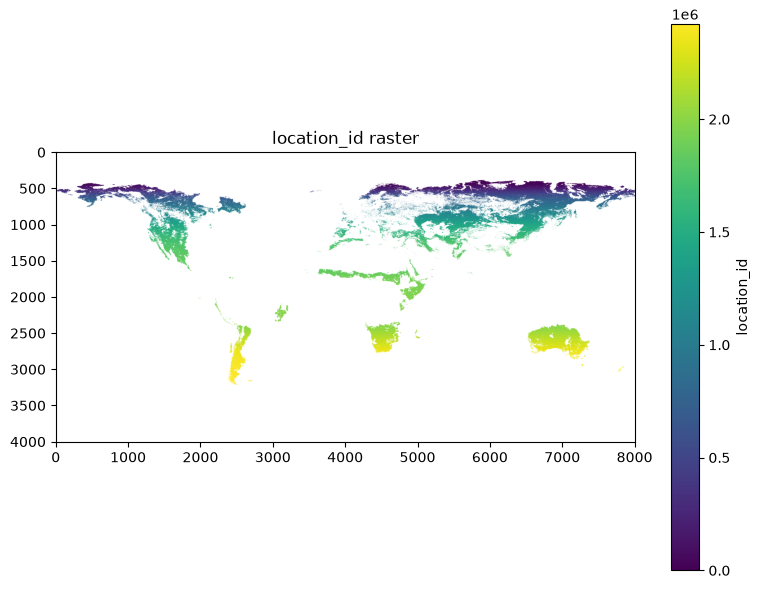

In [3]:
# ======================================================================
# ---------- 1. Visualize location_id.tif ----------
# ======================================================================

with rasterio.open(location_id_raster_path) as src:
    id_band = src.read(1, masked=True)

plt.figure(figsize=(8, 6))
plt.imshow(id_band, cmap="viridis")
plt.colorbar(label="location_id")
plt.title("location_id raster")
plt.tight_layout()
plt.show()

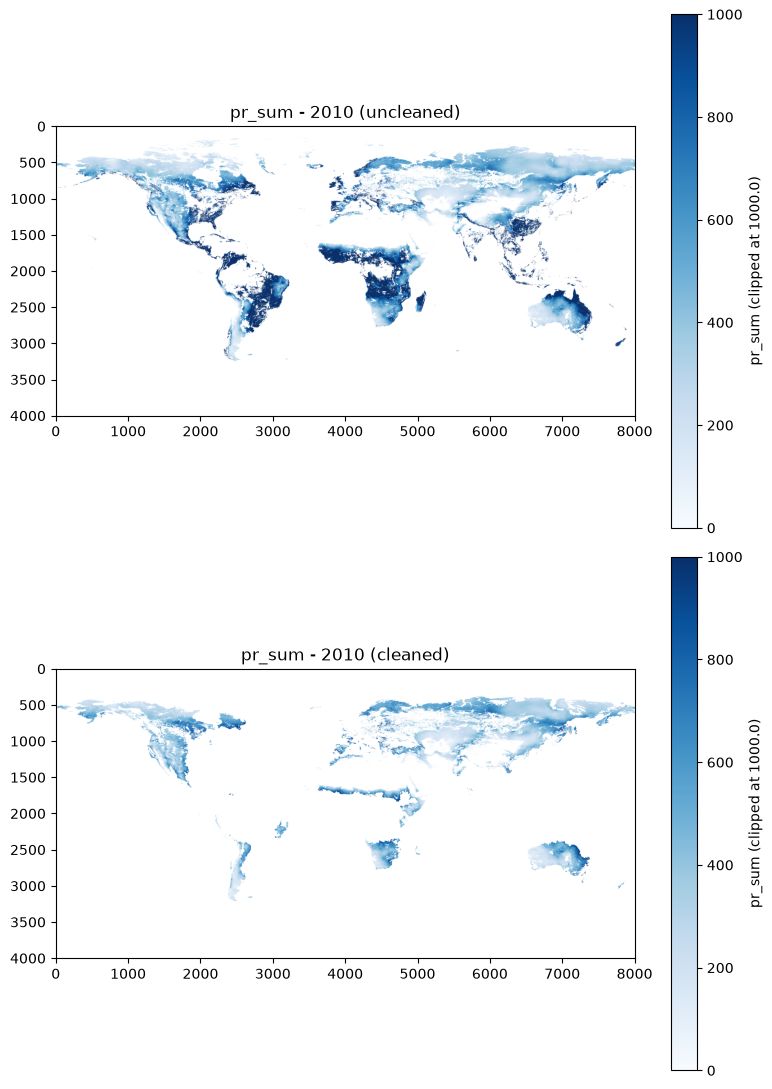

In [10]:
# ======================================================================
# ---------- 2. Visualize pr_sum band of one yearly raster ----------
# ======================================================================

raw_yearly_raster_path = Path(
    f"/Users/Wanja/Documents/non-equilibrium_data/rasters_wgs84_new/stack_wgs84_{YEAR_TO_INSPECT}_rue.tif"
)

def read_band(path, var_name):
    with rasterio.open(path) as src:
        band_names = src.descriptions
        if var_name not in band_names:
            raise ValueError(f"{var_name} not found in bands: {band_names}")
        band_idx = band_names.index(var_name) + 1  # rasterio bands are 1-indexed
        return src.read(band_idx, masked=True)

pr_band_raw = read_band(raw_yearly_raster_path, PRECIP_VAR)
pr_band_clean = read_band(yearly_raster_path, PRECIP_VAR)

fig, axes = plt.subplots(2, 1, figsize=(8, 11))

im0 = axes[0].imshow(pr_band_raw, cmap="Blues", vmin=0, vmax=PRECIP_THRESHOLD)
axes[0].set_title(f"{PRECIP_VAR} - {YEAR_TO_INSPECT} (uncleaned)")
fig.colorbar(im0, ax=axes[0], label=f"{PRECIP_VAR} (clipped at {PRECIP_THRESHOLD})")

im1 = axes[1].imshow(pr_band_clean, cmap="Blues", vmin=0, vmax=PRECIP_THRESHOLD)
axes[1].set_title(f"{PRECIP_VAR} - {YEAR_TO_INSPECT} (cleaned)")
fig.colorbar(im1, ax=axes[1], label=f"{PRECIP_VAR} (clipped at {PRECIP_THRESHOLD})")

plt.tight_layout()
plt.savefig(out_dir_rasters / f"check_{PRECIP_VAR}_{YEAR_TO_INSPECT}_raw_vs_clean.png", dpi=150)
plt.show()

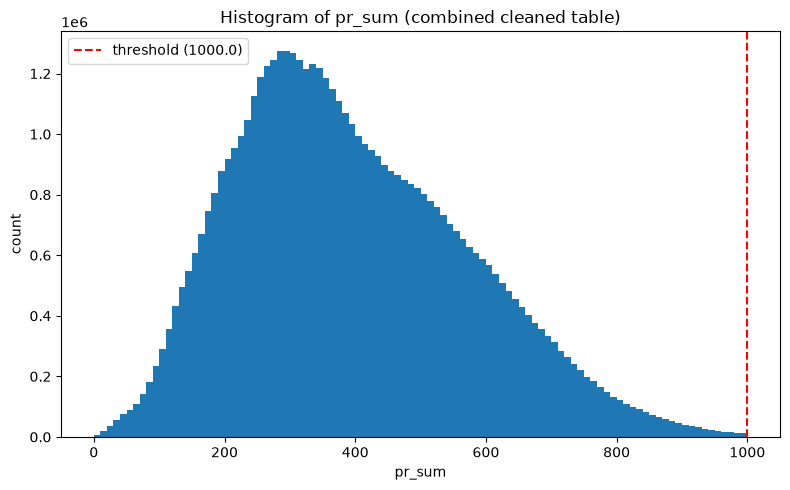

In [5]:
# ======================================================================
# ---------- 3. Histogram of pr_sum in the combined table ----------
# ======================================================================

big_df = pd.read_parquet(big_table_path)

plt.figure(figsize=(8, 5))
plt.hist(big_df[PRECIP_VAR].dropna(), bins=100)
plt.axvline(PRECIP_THRESHOLD, color="red", linestyle="--", label=f"threshold ({PRECIP_THRESHOLD})")
plt.xlabel(PRECIP_VAR)
plt.ylabel("count")
plt.title(f"Histogram of {PRECIP_VAR} (combined cleaned table)")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# ======================================================================
# ---------- 4. Recommended additional checks ----------
# ======================================================================

print("\n--- Additional checks ---\n")

# 4a. Confirm the exclusion actually worked: no value should exceed the threshold
n_over = (big_df[PRECIP_VAR] > PRECIP_THRESHOLD).sum()
print(f"[precip] rows still above threshold in cleaned table: {n_over} (expect 0)")

# 4b. Confirm no unexpected NAs remain (per column)
na_counts = big_df.isna().sum()
na_counts = na_counts[na_counts > 0]
if na_counts.empty:
    print("[NA check] no NAs remain in any column")
else:
    print("[NA check] columns still containing NAs (should only be exempt vars, if any):")
    print(na_counts)

# 4c. Every pixel has the expected number of years, and no duplicate pixel-years
counts_per_pixel = big_df.groupby(ID_COL)["year"].nunique()
years_expected = big_df["year"].nunique()
n_incomplete = (counts_per_pixel != years_expected).sum()
print(f"[completeness] pixels missing a year: {n_incomplete} / {len(counts_per_pixel)}")

dupes = big_df.duplicated(subset=[ID_COL, "year"]).sum()
print(f"[duplicates] duplicate (location_id, year) rows: {dupes} (expect 0)")

# 4d. location_id values are unique and contiguous (0..N-1), matching the lookup table
id_lookup = pd.read_parquet(id_lookup_path)
expected_ids = set(range(len(id_lookup)))
actual_ids = set(id_lookup[ID_COL])
print(f"[id integrity] lookup IDs match expected 0..N-1 range: {actual_ids == expected_ids}")
print(f"[id integrity] table location_ids all present in lookup: "
      f"{set(big_df[ID_COL].unique()).issubset(actual_ids)}")

# 4e. Cross-check table vs raster: does the number of non-nodata pixels in
#     location_id.tif match the number of unique pixels in the table/lookup?
n_raster_pixels = int((~id_band.mask).sum()) if np.ma.is_masked(id_band) else int((id_band != -1).sum())
n_table_pixels = big_df[ID_COL].nunique()
print(f"[table vs raster] unique pixels in table: {n_table_pixels}, "
      f"non-nodata pixels in location_id.tif: {n_raster_pixels} (should match)")

# 4f. Spot-check: for a handful of random pixels, does the raster's location_id
#     at their (row, col) actually match the ID stored for them in the table?
with rasterio.open(location_id_raster_path) as src:
    transform = src.transform
    sample_pixels = id_lookup.sample(n=min(20, len(id_lookup)), random_state=0)
    rows, cols = rasterio.transform.rowcol(
        transform, sample_pixels["lon_r"].values, sample_pixels["lat_r"].values
    )
    raster_ids_at_points = id_band[rows, cols]
    mismatches = (raster_ids_at_points != sample_pixels[ID_COL].values).sum()
    print(f"[spot-check] mismatches between table location_id and raster location_id "
          f"at {len(sample_pixels)} sampled points: {mismatches} (expect 0)")

# 4g. Per-variable summary stats, to eyeball for implausible values (e.g. negative
#     precipitation, extreme outliers in other variables you haven't bounded)
numeric_cols = big_df.select_dtypes(include=[np.number]).columns.difference(
    ["longitude", "latitude", "year", ID_COL]
)
print("\n[summary stats]")
print(big_df[numeric_cols].describe().T[["min", "mean", "max"]])

# 4h. CRS / extent consistency across yearly rasters (the pipeline assumes these
#     are identical; worth confirming rather than assuming)
print("\n[raster grid consistency]")
import glob
raster_files = sorted(out_dir_rasters.glob("stack_wgs84_*_clean.tif"))
ref_profile = None
for f in raster_files:
    with rasterio.open(f) as src:
        prof = (src.crs, src.transform, src.width, src.height)
    if ref_profile is None:
        ref_profile = prof
        ref_file = f
    elif prof != ref_profile:
        print(f"  MISMATCH: {f.name} differs from {ref_file.name}")
if ref_profile is not None:
    print(f"  checked {len(raster_files)} rasters against {ref_file.name}'s grid")


--- Additional checks ---

[precip] rows still above threshold in cleaned table: 0 (expect 0)
[NA check] columns still containing NAs (should only be exempt vars, if any):
iso3         593780
name         554466
continent    554466
region       554466
dtype: int64
[completeness] pixels missing a year: 0 / 2423094
[duplicates] duplicate (location_id, year) rows: 0 (expect 0)
[id integrity] lookup IDs match expected 0..N-1 range: True
[id integrity] table location_ids all present in lookup: True
[table vs raster] unique pixels in table: 2423094, non-nodata pixels in location_id.tif: 2423094 (should match)
[spot-check] mismatches between table location_id and raster location_id at 20 sampled points: 0 (expect 0)

[summary stats]
                          min         mean           max
Gpp                294.908783  6381.496582  65531.738281
Npp                  0.000000  2694.745117  21955.972656
Npp_QC               0.000000    28.806873     99.865982
Npp_cv               1.763741    23